# Machine Learning distribuido con Apache Spark
## *Contratación de profesionales*

---
Una empresa de tamaño mediano quiere predecir cuántos días tardará en cubrir una vacante abierta. Esta estimación le permitirá planificar reemplazos y comunicar plazos realistas a los responsables de cada área.

Archivo de datos: https://raw.githubusercontent.com/encinasquille/DataScience/refs/heads/main/datasets/contratacion_profesionales_ES.txt


| Variable | Descripción |
|---|---|
| `id_vacante` | Código de identificación de la vacante. |
| `seniority` | Nivel de la vacante: junior, pleno, senior o gerente. |
| `area` | Área de la vacante: tecnología, ventas, operaciones o administrativo. |
| `modalidad_trabajo` | Modalidad presencial, híbrida o remota. |
| `requiere_ingles` | Indica si la vacante exige inglés: si o no. |
| `salario_vs_mercado_pct` | Salario ofrecido respecto a la mediana del mercado, en porcentaje. Un valor negativo indica que está por debajo del mercado. |
| `num_candidatos_primera_semana` | Número de candidaturas recibidas durante los primeros siete días. |
| `experiencia_reclutador_anios` | Años de experiencia del reclutador responsable. |
| `num_etapas_proceso` | Número de etapas del proceso de selección. |
| `dias_para_cubrir` | Días entre la apertura de la vacante y la aceptación de la oferta. **Es la variable objetivo.** |



**Objetivo.**

Construir y comparar modelos de regresión con **PySpark y Apache Spark MLlib** para predecir `dias_para_cubrir`. Evaluaremos su desempeño con datos de prueba (test) y seleccionaremos el modelo más adecuado.

> El conjunto contiene solamente 500 observaciones. El ejemplo enseña la **interfaz y la ejecución distribuida**; con una base tan pequeña, Spark puede tardar más que una herramienta local por la sobrecarga de coordinación.

> El conjunto original contiene 500 vacantes. Con este tamaño podemos aprender a usar el pipeline de Spark, pero la coordinación entre el nodo principal y los dos workers puede tomar más tiempo que el propio procesamiento. Para observar mejor la ejecución distribuida en nuestro clúster, probaremos después con 300.000 vacantes sintéticas y, si el tiempo lo permite, con 1.000.000, comparando las tareas y los tiempos de ejecución.

| Etapa | Tamaño | Propósito |
|---|---:|---|
| Explicación y revisión del *pipeline* | 500 filas | Entender las transformaciones y comprobar que los modelos funcionan. |
| Laboratorio distribuido | 300.000 filas sintéticas | Ejecutar los cuatro modelos y observar cómo Spark distribuye el trabajo. |
| Ampliación opcional | 1.000.000 de filas sintéticas | Comparar tiempos, particiones y tareas con la etapa anterior, si hay tiempo y recursos disponibles. |

**Preparación.** Ejecute sobre EMR/Jupyter u otro entorno con **Spark 3.5** y acceso al archivo tabulado `contratacion_profesionales_ES.txt`. Modifique `DATA_URI` a una ruta absoluta de S3 (`s3://...`).

### Sesión de Spark y configuración
`SparkSession` conecta el notebook con el motor distribuido. Un DataFrame de Spark mantiene operaciones repartidas entre particiones; las acciones como `count()` y `show()` materializan cálculos. No convierta toda la tabla a pandas para entrenar.

In [1]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import Imputer, StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

Starting Spark application


ID,YARN Application ID,Kind,State,Spark UI,Driver log,User,Current session?
0,application_1790631882822_0001,pyspark,idle,Link,Link,None,✔


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

SparkSession available as 'spark'.


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [2]:
# Crear una sesión de Spark para trabajar con DataFrames y modelos de MLlib.
# appName asigna un nombre a la aplicación, visible en la interfaz de Spark.
# getOrCreate reutiliza una sesión existente o crea una nueva si todavía no existe.

spark = SparkSession.builder.appName("MLlib_Contratacion_profesionales").getOrCreate()
print("Versión de Spark:", spark.version)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Versi?n de Spark: 3.5.6-amzn-2

In [3]:
# Definir la ruta del archivo de entrada en Amazon S3.
data_source = "s3://seccion-b-rosa-lab1/contratacion_profesionales_ES.txt"

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [4]:
# Cargar datos
datos = spark.read.option("header", "true").option("sep", "\t").option("inferSchema", "true").csv(data_source)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [5]:
# Comprobar que los datos se cargaron correctamente.
datos.printSchema()
datos.show(5, truncate=False)
print("Vacantes:", datos.count(), " Columnas:", len(datos.columns))

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

root
 |-- id_vacante: string (nullable = true)
 |-- seniority: string (nullable = true)
 |-- area: string (nullable = true)
 |-- modalidad_trabajo: string (nullable = true)
 |-- requiere_ingles: string (nullable = true)
 |-- salario_vs_mercado_pct: double (nullable = true)
 |-- num_candidatos_primera_semana: integer (nullable = true)
 |-- experiencia_reclutador_anios: integer (nullable = true)
 |-- num_etapas_proceso: integer (nullable = true)
 |-- dias_para_cubrir: integer (nullable = true)

+----------+---------+--------------+-----------------+---------------+----------------------+-----------------------------+----------------------------+------------------+----------------+
|id_vacante|seniority|area          |modalidad_trabajo|requiere_ingles|salario_vs_mercado_pct|num_candidatos_primera_semana|experiencia_reclutador_anios|num_etapas_proceso|dias_para_cubrir|
+----------+---------+--------------+-----------------+---------------+----------------------+----------------------------

In [6]:
# Configuración del modelado
SEED = 123
LABEL = "dias_para_cubrir"
ID = "id_vacante"

NUMERICAS = [
    "salario_vs_mercado_pct",
    "num_candidatos_primera_semana",
    "experiencia_reclutador_anios",
    "num_etapas_proceso"
]

CATEGORICAS = [
    "seniority",
    "area",
    "modalidad_trabajo",
    "requiere_ingles"
]

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

### Exploración y calidad de datos
Spark calcula resúmenes y frecuencias en el clúster. `show()` devuelve solo unas filas al controlador. Contamos los faltantes antes de tratarlos y verificamos los valores de la respuesta. El identificador sirve para localizar vacantes, **no** se usará como predictor.

In [7]:
# Valores ausentes (incluye NaN en columnas numéricas)
faltantes = [F.sum(F.when(F.col(c).isNull() | (F.isnan(F.col(c)) if c in NUMERICAS + [LABEL] else F.lit(False)), 1).otherwise(0)).alias(c) for c in datos.columns]
datos.select(*faltantes).show(truncate=False)

# Resumen de las variables numéricas y la respuesta
datos.select(*(NUMERICAS + [LABEL])).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show(truncate=False)

# Categorías y frecuencias
for c in CATEGORICAS:
    print("Categorías de", c)
    datos.groupBy(c).count().orderBy(F.desc("count")).show(truncate=False)

# Vacantes que tardaron más de 365 días
print("Vacantes con más de 365 días:", datos.filter(F.col(LABEL) > 365).count())
datos.filter(F.col(LABEL) > 365).select(ID, LABEL).show(truncate=False)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+----------+---------+----+-----------------+---------------+----------------------+-----------------------------+----------------------------+------------------+----------------+
|id_vacante|seniority|area|modalidad_trabajo|requiere_ingles|salario_vs_mercado_pct|num_candidatos_primera_semana|experiencia_reclutador_anios|num_etapas_proceso|dias_para_cubrir|
+----------+---------+----+-----------------+---------------+----------------------+-----------------------------+----------------------------+------------------+----------------+
|0         |0        |0   |0                |2              |3                     |0                            |0                           |0                 |0               |
+----------+---------+----+-----------------+---------------+----------------------+-----------------------------+----------------------------+------------------+----------------+

+-------+----------------------+-----------------------------+----------------------------+--------

**Regla del caso.** El ejercicio establece que una vacante abierta más de 365 días se cancela, por lo que plazos superiores a ese valor representan un error de registro. Conservamos los plazos altos que aún cumplen la regla. No utilizamos los cuartiles del conjunto de prueba para fijar el corte. Las columnas numéricas faltantes se imputarán **dentro** del pipeline, ajustando la mediana por cada fold de entrenamiento; las categorías faltantes o nuevas se codifican como grupo adicional.

**Disponibilidad temporal:** `num_candidatos_primera_semana` solo existe después del día 7. No interprete estas predicciones como pronósticos hechos el día de apertura. Para producción harían falta validación temporal, auditoría de fuentes y decisiones de negocio adicionales.

In [8]:
# Conservar las vacantes que cumplen la regla del ejercicio
limpios = datos.filter(F.col(LABEL).isNotNull() & (F.col(LABEL) > 0) & (F.col(LABEL) <= 365))
print("Filas válidas:", limpios.count())

# Comparar los días para cubrir una vacante según la senioridad
limpios.groupBy("seniority").agg(
    F.count("*").alias("vacantes"),
    F.round(F.avg(LABEL), 2).alias("promedio_dias"),
    F.round(F.expr(f"percentile_approx({LABEL}, 0.5)"), 2).alias("mediana_dias")
).orderBy("seniority").show()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Filas v?lidas: 498
+---------+--------+-------------+------------+
|seniority|vacantes|promedio_dias|mediana_dias|
+---------+--------+-------------+------------+
|  gerente|      54|        84.83|          78|
|   junior|     179|        19.54|          18|
|    pleno|     171|        34.19|          31|
|   senior|      94|        70.95|          63|
+---------+--------+-------------+------------+

### Separar entrenamiento y prueba
`randomSplit` hace una separación reproducible aproximada 80/20. En un caso real con cambios en el tiempo, separar por fecha puede representar mejor el uso futuro. El test se evalúa después de elegir el modelo con validación cruzada; no interviene en la imputación, búsqueda ni elección.

In [9]:
train, test = limpios.randomSplit([0.8, 0.2], seed=SEED)
train.cache(); test.cache()
print("Entrenamiento:", train.count(), " prueba:", test.count())

assert train.count() > 0 and test.count() > 0
assert train.select(ID).distinct().count() == train.count()
assert test.select(ID).distinct().count() == test.count()
assert train.select(ID).join(test.select(ID), on=ID, how="inner").count() == 0

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Entrenamiento: 398  prueba: 100

### Conceptos del pipeline

| Concepto | Papel en este notebook |
|---|---|
| **Transformer** | `VectorAssembler.transform()` crea columnas de características. |
| **Estimator** | `Imputer`, `StringIndexer`, `OneHotEncoder`, `StandardScaler` y cada regresor aprenden durante `fit()`. |
| **Pipeline** | Encadena preparación y regresor; `fit(train)` genera un `PipelineModel`. |
| **ParamGridBuilder** | Construye las configuraciones candidatas para un regresor. |
| **Evaluator** | Mide el RMSE de cada predicción de validación. |
| **CrossValidator** | Reajusta el pipeline completo en cada fold y obtiene `bestModel`. |

El ajuste de preprocesadores sucede dentro de cada fold. Esto evita aprender medianas, vocabularios o escalas usando los folds de validación. El pipeline contiene **etapas** de preparación y predicción; `ParamGridBuilder`, `Evaluator` y `CrossValidator` envuelven el pipeline en la etapa de selección.

In [16]:
def construir_pipeline(regresor):
    """Preprocesamiento y regresor ajustados dentro de cada fold."""
    numericas_imp = [c + "_imp" for c in NUMERICAS]
    indices = [c + "_idx" for c in CATEGORICAS]
    vectores_cat = [c + "_oh" for c in CATEGORICAS]

    imputer = Imputer(inputCols=NUMERICAS, outputCols=numericas_imp, strategy="median")
    indexador = StringIndexer(inputCols=CATEGORICAS, outputCols=indices, handleInvalid="keep")
    onehot = OneHotEncoder(inputCols=indices, outputCols=vectores_cat, dropLast=True)
    es_lineal = isinstance(regresor, LinearRegression)
    ensamblador = VectorAssembler(inputCols=numericas_imp + vectores_cat,fboosting
                                  outputCol="features_raw" if es_lineal else "features")

    etapas = [imputer, indexador, onehot, ensamblador]
    if es_lineal:
        etapas.append(StandardScaler(inputCol="features_raw", outputCol="features",
                                     withMean=False, withStd=True))

    regresor.setLabelCol(LABEL)
    return Pipeline(stages=etapas + [regresor])

evaluador_rmse = RegressionEvaluator(labelCol=LABEL, predictionCol="prediction", metricName="rmse")
print("Etapas:", [type(s).__name__ for s in construir_pipeline(LinearRegression()).getStages()])

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Etapas: ['Imputer', 'StringIndexer', 'OneHotEncoder', 'VectorAssembler', 'StandardScaler', 'LinearRegression']

### Cuatro modelos y sus hiperparámetros
`GBTRegressor` es el boosting incluido en `pyspark.ml`, en lugar del `XGBRegressor` local. La regresión lineal aquí usa todas las variables y explora regularización; no reproduce la eliminación por valores p del ejemplo con `statsmodels`. Los rangos son pequeños para una práctica; en un proyecto se justificarían con presupuesto computacional y comportamiento de los modelos.

In [23]:
regresores = {
    "Regresión lineal": LinearRegression(featuresCol="features", labelCol=LABEL, maxIter=80),
    "Árbol de regresión": DecisionTreeRegressor(featuresCol="features", labelCol=LABEL,
                                                minInstancesPerNode=8, seed=SEED),
    "Random forest": RandomForestRegressor(featuresCol="features", labelCol=LABEL,
                                           minInstancesPerNode=5, seed=SEED),
    "Gradient boosting": GBTRegressor(featuresCol="features", labelCol=LABEL,
                                      minInstancesPerNode=5, seed=SEED)
}

grids = {
    "Regresión lineal": ParamGridBuilder()
        .addGrid(regresores["Regresión lineal"].regParam, [0.01, 0.1]).build(),

    "Árbol de regresión": ParamGridBuilder()
        .addGrid(regresores["Árbol de regresión"].maxDepth, [3, 5]).build(),

    "Random forest": ParamGridBuilder()
        .addGrid(regresores["Random forest"].numTrees, [30, 60])
        .addGrid(regresores["Random forest"].maxDepth, [4, 6]).build(),

    "Gradient boosting": ParamGridBuilder()
        .addGrid(regresores["Gradient boosting"].maxIter, [40, 80])
        .addGrid(regresores["Gradient boosting"].maxDepth, [2, 3])
        .addGrid(regresores["Gradient boosting"].stepSize, [0.05, 0.10]).build()
}

print("Configuraciones por modelo:", {nombre: len(grid) for nombre, grid in grids.items()})
print("Entrenamientos en CV (3 folds):", sum(3 * len(grid) for grid in grids.values()))
print("Reajustes finales:", len(regresores))

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Configuraciones por modelo: {'Regresi?n lineal': 2, '?rbol de regresi?n': 2, 'Random forest': 4, 'Gradient boosting': 8}
Entrenamientos en CV (3 folds): 48
Reajustes finales: 4

### Validación cruzada y selección
Cada `CrossValidator` recibe un `Pipeline` como `estimator`, una rejilla de parámetros y un `Evaluator`. Con tres folds selecciona la configuración con menor **RMSE medio**; Spark reajusta el mejor pipeline con todo `train`. Entrenar árboles/GBT en varios folds puede tardar minutos en un laboratorio compartido. Ajuste tamaño de rejilla, paralelismo y memoria a los recursos disponibles. Para un diagnóstico exhaustivo harían falta otros rangos y más datos.

In [24]:
cv_models = {}
resumen_cv = []

for nombre, regresor in regresores.items():
    cv = CrossValidator(
        estimator=construir_pipeline(regresor),
        estimatorParamMaps=grids[nombre],
        evaluator=evaluador_rmse,
        numFolds=3, seed=SEED, parallelism=2,
        collectSubModels=False
    )

    print("Ajustando:", nombre, "| configuraciones:", len(grids[nombre]))
    ajustado = cv.fit(train)
    cv_models[nombre] = ajustado

    mejor_i = min(range(len(ajustado.avgMetrics)), key=lambda i: ajustado.avgMetrics[i])
    mejores_params = {p.name: v for p, v in grids[nombre][mejor_i].items()}
    resultado = {"modelo": nombre, "rmse_cv": float(ajustado.avgMetrics[mejor_i]),
                 "hiperparametros": mejores_params}
    resumen_cv.append(resultado)
    print("  RMSE CV:", round(resultado["rmse_cv"], 3), "| parámetros:", mejores_params)

resumen_cv.sort(key=lambda fila: fila["rmse_cv"])
for fila in resumen_cv:
    print(fila)

mejor_nombre = resumen_cv[0]["modelo"]
mejor_pipeline = cv_models[mejor_nombre].bestModel
print("Modelo seleccionado por validación cruzada:", mejor_nombre)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Ajustando: Regresi?n lineal | configuraciones: 2
  RMSE CV: 15.899 | par?metros: {'regParam': 0.1}
Ajustando: ?rbol de regresi?n | configuraciones: 2
  RMSE CV: 16.58 | par?metros: {'maxDepth': 5}
Ajustando: Random forest | configuraciones: 4
  RMSE CV: 13.804 | par?metros: {'numTrees': 30, 'maxDepth': 6}
Ajustando: Gradient boosting | configuraciones: 8
  RMSE CV: 13.555 | par?metros: {'maxIter': 80, 'maxDepth': 2, 'stepSize': 0.1}
{'modelo': 'Gradient boosting', 'rmse_cv': 13.555485953582968, 'hiperparametros': {'maxIter': 80, 'maxDepth': 2, 'stepSize': 0.1}}
{'modelo': 'Random forest', 'rmse_cv': 13.804087535581994, 'hiperparametros': {'numTrees': 30, 'maxDepth': 6}}
{'modelo': 'Regresi?n lineal', 'rmse_cv': 15.899240584990467, 'hiperparametros': {'regParam': 0.1}}
{'modelo': '?rbol de regresi?n', 'rmse_cv': 16.57967894590797, 'hiperparametros': {'maxDepth': 5}}
Modelo seleccionado por validaci?n cruzada: Gradient boosting

###  Evaluación final en prueba
Después de fijar el ganador con `train`, evaluamos los cuatro modelos en el mismo conjunto reservado para **comparación descriptiva**; no volvemos a elegir el ganador con estas cifras. RMSE y MAE se expresan en días. El MAPE puede calcularse porque excluimos respuestas no positivas. Una gran diferencia entre error de entrenamiento y prueba sugiere revisar generalización, aunque con ~500 registros las métricas varían según la división.

In [25]:
metricas = {m: RegressionEvaluator(labelCol=LABEL, predictionCol="prediction", metricName=m)
            for m in ("rmse", "mae", "r2")}

comparacion = []
for fila in resumen_cv:
    nombre = fila["modelo"]
    modelo = cv_models[nombre].bestModel
    pred_train = modelo.transform(train).select(LABEL, "prediction")
    pred_test = modelo.transform(test).select(LABEL, "prediction")

    rmse_train = metricas["rmse"].evaluate(pred_train)
    rmse_test = metricas["rmse"].evaluate(pred_test)
    mae_test = metricas["mae"].evaluate(pred_test)
    r2_test = metricas["r2"].evaluate(pred_test)
    mape_test = pred_test.select(
        (F.avg(F.abs(F.col(LABEL) - F.col("prediction")) / F.col(LABEL)) * 100).alias("mape")
    ).first()["mape"]

    comparacion.append((nombre, round(fila["rmse_cv"], 3), round(rmse_train, 3),
                        round(rmse_test, 3), round(mae_test, 3),
                        round(mape_test, 2), round(r2_test, 3)))

campos = ["modelo", "RMSE_CV", "RMSE_entrenamiento", "RMSE_prueba",
          "MAE_prueba", "MAPE_prueba_pct", "R2_prueba"]
comparacion_df = spark.createDataFrame(comparacion, campos).orderBy("RMSE_CV")
comparacion_df.show(truncate=False)
print("Modelo seleccionado por validación cruzada:", mejor_nombre)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+------------------+-------+------------------+-----------+----------+---------------+---------+
|modelo            |RMSE_CV|RMSE_entrenamiento|RMSE_prueba|MAE_prueba|MAPE_prueba_pct|R2_prueba|
+------------------+-------+------------------+-----------+----------+---------------+---------+
|Gradient boosting |13.555 |7.959             |10.782     |7.037     |17.36          |0.855    |
|Random forest     |13.804 |9.771             |10.048     |6.634     |17.49          |0.874    |
|Regresi?n lineal  |15.899 |15.181            |10.799     |8.069     |25.99          |0.855    |
|?rbol de regresi?n|16.58  |13.015            |16.156     |9.568     |21.32          |0.675    |
+------------------+-------+------------------+-----------+----------+---------------+---------+

Modelo seleccionado por validaci?n cruzada: Gradient boosting

In [15]:
# Diagnóstico distribuido del modelo seleccionado (sin traer todos los registros al driver).
diagnostico = mejor_pipeline.transform(test).select(ID, LABEL, "prediction")
diagnostico = diagnostico.withColumn("residuo", F.col(LABEL) - F.col("prediction"))
# Distribución de los residuos
diagnostico.select("residuo").summary("count", "mean", "stddev", "min", "max").show()
# Diez vacantes con mayor error de predicción
diagnostico.orderBy(F.desc(F.abs(F.col("residuo")))).show(10, truncate=False)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------+-------------------+
|summary|            residuo|
+-------+-------------------+
|  count|                100|
|   mean|-0.7526609463818221|
| stddev| 10.187951967196213|
|    min| -32.84961243386243|
|    max|   44.9857211205189|
+-------+-------------------+

+----------+----------------+------------------+-------------------+
|id_vacante|dias_para_cubrir|prediction        |residuo            |
+----------+----------------+------------------+-------------------+
|V0158     |101             |56.0142788794811  |44.9857211205189   |
|V0253     |145             |110.82253342470737|34.17746657529263  |
|V0491     |103             |69.92172182889574 |33.07827817110426  |
|V0036     |44              |76.84961243386243 |-32.84961243386243 |
|V0269     |98              |68.42179463546454 |29.578205364535464 |
|V0456     |92              |110.4192664742665 |-18.419266474266493|
|V0195     |50              |32.7018537988538  |17.298146201146203 |
|V0156     |80              |96.2199368

### Predicción y persistencia
`CrossValidatorModel.bestModel` es el `PipelineModel` completo: transforma nuevos registros con el mismo preprocesamiento aprendido y produce la columna `prediction`. La predicción no exige la respuesta observada. Escriba en S3/HDFS una ruta accesible si desea compartir el modelo entre sesiones. Para uso real, registre también versión de datos, esquema y fecha de ajuste.

In [26]:
nuevas_vacantes = spark.createDataFrame([
    {"id_vacante": "N001", "seniority": "junior", "area": "tecnología",
     "modalidad_trabajo": "remoto", "requiere_ingles": "si",
     "salario_vs_mercado_pct": 5.0, "num_candidatos_primera_semana": 35,
     "experiencia_reclutador_anios": 8, "num_etapas_proceso": 3},

    {"id_vacante": "N002", "seniority": "senior", "area": "ventas",
     "modalidad_trabajo": "presencial", "requiere_ingles": "no",
     "salario_vs_mercado_pct": -10.0, "num_candidatos_primera_semana": 9,
     "experiencia_reclutador_anios": 4, "num_etapas_proceso": 5}
], schema=train.drop(LABEL).schema)

mejor_pipeline.transform(nuevas_vacantes) \
    .select(ID, F.round("prediction", 1).alias("dias_estimados")) \
    .show(truncate=False)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+----------+--------------+
|id_vacante|dias_estimados|
+----------+--------------+
|N001      |17.4          |
|N002      |70.9          |
+----------+--------------+

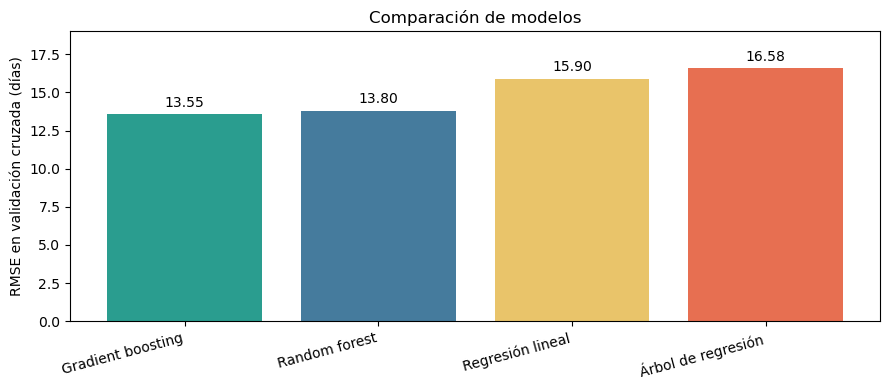

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt

modelos = ["Gradient boosting", "Random forest", "Regresión lineal", "Árbol de regresión"]
rmse_cv = [13.555, 13.804, 15.899, 16.580]

plt.figure(figsize=(9, 4))
barras = plt.bar(modelos, rmse_cv, color=["#2a9d8f", "#457b9d", "#e9c46a", "#e76f51"])
plt.bar_label(barras, fmt="%.2f", padding=3)
plt.ylabel("RMSE en validación cruzada (días)")
plt.title("Comparación de modelos")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 19)
plt.tight_layout()
plt.show()

### Preguntas para discusión
1. ¿Qué información está disponible al abrir la vacante y qué cambia al final de la primera semana?
2. ¿Por qué deben aprenderse la mediana, las categorías y el escalado **dentro** de cada fold?
3. ¿Por qué el RMSE del test no debe usarse para decidir entre las cuatro técnicas?
4. ¿Qué indica una caída de rendimiento entre entrenamiento y prueba?
5. ¿Qué cambiaría en la evaluación si el objetivo fuera estimar el plazo de **futuras** vacantes con datos históricos fechados?

*Trabajo bonus: ampliación del laboratorio (puntos extra)*

La base inicial contiene aproximadamente 500 vacantes. Como actividad opcional, generen datos sintéticos con la misma estructura para ejecutar el pipeline con conjuntos más grandes:

- 300.000 registros: entrenen los cuatro modelos y registren el tiempo de ejecución, el número de particiones y las métricas de evaluación.

- 1.000.000 de registros: repitan el experimento y comparen los resultados con los obtenidos para 300.000 registros.

Presenten una tabla comparativa y expliquen: ¿cómo cambió el tiempo de ejecución?, ¿qué trabajo se distribuyó entre los workers?, ¿aumentar el número de registros sintéticos mejoró necesariamente la calidad de las predicciones?

> **Importante:** los datos sintéticos deben conservar relaciones plausibles entre las variables y dias_para_cubrir. Obtener un buen RMSE con datos sintéticos no demuestra que el modelo funcionará igual de bien con vacantes reales.
> Presenten una tabla que compare 500, 300.000 y 1.000.000 de registros y respondan:
> ¿Cómo cambió el tiempo de ejecución al aumentar los datos?
> ¿Se aprovecharon los dos workers del clúster? ¿Qué evidencia ofrece la Spark UI?
> ¿Hubo tareas mucho más lentas que otras o movimientos de datos entre nodos?
> ¿En qué casos la sobrecarga de coordinación de Spark fue significativa?
>¿Aumentar la cantidad de datos sintéticos mejoró necesariamente las predicciones? ¿Por qué?

Entrega: código de generación de datos, tabla comparativa, capturas relevantes de la Spark UI y una breve interpretación de los resultados. Los datos sintéticos deben conservar relaciones plausibles entre las variables y dias_para_cubrir; su rendimiento predictivo no debe interpretarse como evidencia de desempeño con vacantes reales.


**Fuentes técnicas:**

ML Pipelines https://spark.apache.org/docs/3.5.6/ml-pipeline.html

ML Tuning https://spark.apache.org/docs/3.5.6/ml-tuning.html

API de regresión PySpark https://spark.apache.org/docs/3.5.6/api/python/reference/pyspark.ml.html.

